# **Full Model Validation**

In [5]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)
RNG = np.random.default_rng(42)

## **Introduction**

This notebook answers the question the approval model notebook cannot: **would this policy have actually worked?**

The EP calculation in the approval model is a point estimate — it uses the mean predicted PD, LGD, and EAD for each loan. In reality:
- Model predictions carry uncertainty (epistemic)
- Macro conditions shift over time (temporal)
- Individual loan outcomes are stochastic (aleatoric)

This simulation addresses all three with a two-layer structure:

**Layer 1 — Rolling Window Backtest:** train/approve/observe in expanding annual windows matching the actual dataset timeline. At each step, the approval policy is applied to loans issued in year $t$, and the *realised* EP is computed from actual outcomes (`is_default`, `recoveries`, `total_rec_prncp`). This tells us how the policy would have performed historically.

**Layer 2 — Monte Carlo within each window:** at each window, instead of using point-predicted PD/LGD/EAD, sample from their uncertainty distributions $N$ times. Each trial produces a different approved book and a different EP outcome. The result is a **distribution of outcomes per vintage**, not just a single number.

Together these give:
- **Expected EP** and **confidence intervals** by vintage year
- **Value at Risk (VaR)** and **CVaR** on the portfolio EP
- **Stress testing** — the lower tail of the Monte Carlo distribution is the stress scenario
- **Hurdle rate calibration** — which hurdle maximises *realised* EP in the backtest, not just predicted EP

## **Load Data & Models**

In [6]:
from credit_risk_pipeline import (
    # Clases de Preprocesamiento (PD, LGD, EAD)
    ColumnNameCleaner, EmpLengthTransformer, CategoricalCleaner, 
    TermTransformer, LoanStatusCleaner, GradeTransformer, 
    IssueDateTransformer, Winsorizer, WoEEncoder, 
    FeatureDropper, LoanFeatureEngineer, PDPreprocessor, PDModel,
    
    # Clase de Aprobación y funciones financieras
    ApprovalModel, calculate_el, calculate_ep, 
    calculate_income, calculate_el_ratio, calculate_ep_ratio
)

In [7]:
# Loan-level data with predictions and actual outcomes
df = pd.read_parquet('ep_results.parquet')

# ApprovalModel
approval_model = joblib.load('approval_model.pkl')

print(f'Portfolio: {len(df):,} loans | Years: {df["issue_d_year"].min()}–{df["issue_d_year"].max()}')
print(f'Approval model: {approval_model}')
df['issue_d_year'].value_counts().sort_index()

Portfolio: 1,345,310 loans | Years: 2007–2018
Approval model: ApprovalModel(hurdle_rate=0.0000)


issue_d_year
2007       251
2008      1562
2009      4716
2010     11536
2011     21721
2012     53367
2013    134804
2014    223102
2015    375545
2016    293095
2017    169300
2018     56311
Name: count, dtype: int64

## **Realised EP**

The expected EP uses model predictions. The realised EP uses actual outcomes:

$$\text{Realised EP} = \begin{cases}
\text{Income} & \text{if not defaulted} \\
\text{Income} - \text{LGD}_{\text{actual}} \times \text{EAD}_{\text{actual}} & \text{if defaulted}
\end{cases}$$

For defaulted loans, actual LGD = `1 - recoveries/funded_amnt` and actual EAD = `(1 - total_rec_prncp/funded_amnt) × funded_amnt`. These are the same targets used to train the LGD and EAD models — here we use the ground truth instead of the prediction.

The gap between realised and expected EP is the model's forecast error materialised as profit/loss.

In [8]:
# Reload raw data
df_raw = pd.read_parquet('accepted.parquet', columns=[
    'loan_status', 'funded_amnt', 'int_rate', 'issue_d',
    'recoveries', 'total_rec_prncp',
])

# Preprocessing & Normalization
df_raw.columns = df_raw.columns.str.lower().str.strip()

# Standardize status strings to handle potential case/space issues
df_raw['loan_status'] = df_raw['loan_status'].str.lower().str.replace(' ', '_')
df_raw = df_raw[df_raw['loan_status'].isin(['fully_paid', 'charged_off'])].copy()

# Safety Check: Stop early if filtering failed
if df_raw.empty:
    raise ValueError("df_raw is empty after filtering! Check if 'fully_paid' or 'charged_off' exist in the parquet.")

# Feature Engineering
df_raw['is_default'] = (df_raw['loan_status'] == 'charged_off').astype(int)

# Use errors='coerce' and check if any dates failed
df_raw['issue_d'] = pd.to_datetime(df_raw['issue_d'], errors='coerce')
df_raw['issue_d_year'] = df_raw['issue_d'].dt.year

# Calculate Actual LGD and EAD
# We use .replace(0, np.nan) to avoid division by zero
df_raw['lgd_actual'] = np.where(
    df_raw['is_default'] == 1,
    (1 - df_raw['recoveries'] / df_raw['funded_amnt'].replace(0, np.nan)).clip(0, 1),
    0 # Non-defaults have 0 loss
)

df_raw['ead_actual'] = np.where(
    df_raw['is_default'] == 1,
    (1 - df_raw['total_rec_prncp'] / df_raw['funded_amnt'].replace(0, np.nan)).clip(0, 1) * df_raw['funded_amnt'],
    df_raw['funded_amnt']
)

# Merge using Index Alignment
# REMOVED .values to prevent the length mismatch error
df = df.copy()
df['lgd_actual'] = df_raw['lgd_actual']
df['ead_actual'] = df_raw['ead_actual']
df['is_default_actual'] = df_raw['is_default']

# Calculate Realised Expected Profit (EP)
df['ep_realised'] = np.where(
    df['is_default_actual'] == 0,
    df['income'], 
    df['income'] - (df['lgd_actual'] * df['ead_actual'])
)

df['ep_realised_ratio'] = df['ep_realised'] / df['funded_amnt']

print(f"Successfully processed {len(df)} rows.")
df[['ep', 'ep_realised', 'ep_ratio', 'ep_realised_ratio']].describe().round(4)

Successfully processed 1345310 rows.


,ep,ep_realised,ep_ratio,ep_realised_ratio
count,"1,345,310.0000","887,322.0000","1,345,310.0000","887,322.0000"
mean,-609.8522,"5,477.2851",-0.0343,0.2412
std,"2,349.8082","9,158.1458",0.1265,0.9177
min,"-21,528.1404","-38,197.0600",-0.6138,-32.5105
25%,"-1,274.7687","1,717.2000",-0.1032,0.2286
50%,-96.1624,"3,911.7375",-0.0114,0.3636
75%,571.7183,"8,792.0000",0.0599,0.5331
max,"16,951.4796","61,980.0000",0.4806,1.5495


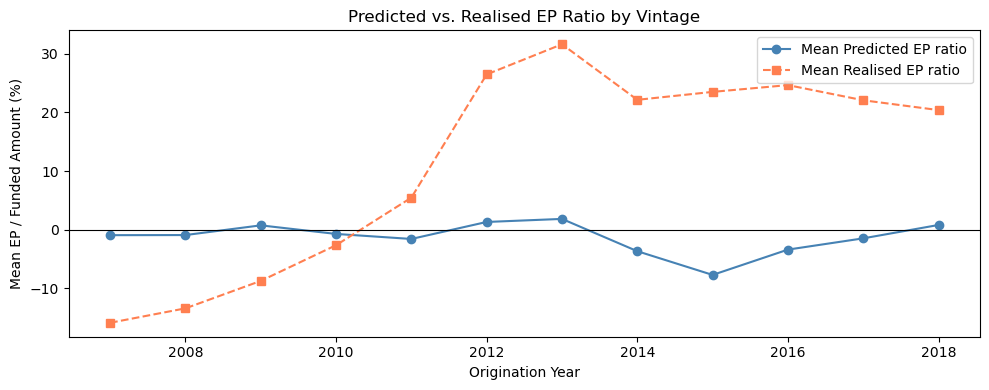

,issue_d_year,mean_ep_pred,mean_ep_real,obs_default
0,2007,-0.0093,-0.1585,0.2222
1,2008,-0.0091,-0.1339,0.2269
2,2009,0.0075,-0.0872,0.2363
3,2010,-0.0071,-0.0264,0.2450
4,2011,-0.0157,0.0546,0.2402
5,2012,0.0132,0.2645,0.1973
6,2013,0.0184,0.3159,0.1954
7,2014,-0.0366,0.2212,0.2315
8,2015,-0.0770,0.2348,0.2020
9,2016,-0.0338,0.2463,0.1957


In [9]:
# Sanity check: expected vs realised EP by year
ep_check = df.groupby('issue_d_year').agg(
    mean_ep_pred   = ('ep_ratio',          'mean'),
    mean_ep_real   = ('ep_realised_ratio',  'mean'),
    obs_default    = ('is_default_actual',  'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ep_check['issue_d_year'], ep_check['mean_ep_pred']  * 100, 'o-', color='steelblue', label='Mean Predicted EP ratio')
ax.plot(ep_check['issue_d_year'], ep_check['mean_ep_real']  * 100, 's--', color='coral',    label='Mean Realised EP ratio')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Predicted vs. Realised EP Ratio by Vintage')
ax.set_xlabel('Origination Year')
ax.set_ylabel('Mean EP / Funded Amount (%)')
ax.legend()
plt.tight_layout()
plt.show()

display(ep_check.round(4))

## **Monte Carlo Uncertainty Model**

For each loan, PD, LGD, and EAD predictions are point estimates. The true values are uncertain. I model this uncertainty with additive Gaussian noise calibrated to each model's residuals on the test set:

- **PD noise:** $\tilde{\text{PD}} = \text{clip}(\text{PD} + \epsilon_{\text{PD}}, 0, 1)$ where $\epsilon_{\text{PD}} \sim \mathcal{N}(0, \sigma_{\text{PD}})$
- **LGD noise:** same structure, calibrated to LGD model MAE
- **EAD noise:** same structure, calibrated to EAD model MAE

Since we have actual outcomes, we can estimate $\sigma$ empirically from the prediction errors. On defaulted loans where both prediction and realisation are available, we compute the residual standard deviation and use that as the noise scale.

Each Monte Carlo trial samples a perturbed set of predictions, applies the approval policy, and computes the expected EP of the resulting approved book. Running $N$ trials gives the EP distribution.

In [10]:
# Estimate prediction uncertainty from empirical residuals on defaulted loans
defaults = df[df['is_default_actual'] == 1].dropna(subset=['lgd_actual', 'ead_actual'])

lgd_residuals = defaults['lgd_actual'] - defaults['lgd_hat']
ead_residuals = (defaults['ead_actual'] / defaults['funded_amnt'].replace(0, np.nan)) - defaults['ead_ratio_hat']

# PD: use calibration error (predicted PD vs observed default rate in deciles)
df['pd_decile'] = pd.qcut(df['pd_score'], q=20, labels=False, duplicates='drop')
cal = df.groupby('pd_decile').agg(
    pred_pd  = ('pd_score',          'mean'),
    obs_rate = ('is_default_actual',  'mean')
)
pd_cal_error = (cal['pred_pd'] - cal['obs_rate']).std()

SIGMA_PD  = max(pd_cal_error, 0.02)   # at least 2pp noise
SIGMA_LGD = lgd_residuals.std()
SIGMA_EAD = ead_residuals.std()

print(f'Noise calibration:')
print(f'  σ_PD  = {SIGMA_PD:.4f}  ({SIGMA_PD:.2%})')
print(f'  σ_LGD = {SIGMA_LGD:.4f}  ({SIGMA_LGD:.2%})')
print(f'  σ_EAD = {SIGMA_EAD:.4f}  ({SIGMA_EAD:.2%})')

Noise calibration:
  σ_PD  = 0.1867  (18.67%)
  σ_LGD = 0.0967  (9.67%)
  σ_EAD = 1.7827  (178.27%)


In [11]:
def monte_carlo_ep(loans: pd.DataFrame,
                   hurdle_rate: float,
                   sigma_pd: float,
                   sigma_lgd: float,
                   sigma_ead: float,
                   n_trials: int = 500,
                   rng=None) -> dict:
    
    if rng is None:
        rng = np.random.default_rng(42)

    n = len(loans)
    pd_base  = loans['pd_score'].values
    lgd_base = loans['lgd_hat'].values
    ead_r_base = loans['ead_ratio_hat'].values
    funded   = loans['funded_amnt'].values
    rate     = loans['int_rate'].values

    trial_total_ep     = np.zeros(n_trials)
    trial_approval_rate = np.zeros(n_trials)
    trial_mean_ep_ratio = np.zeros(n_trials)

    for i in range(n_trials):
        # Perturb predictions
        pd_t   = np.clip(pd_base  + rng.normal(0, sigma_pd,  n), 0, 1)
        lgd_t  = np.clip(lgd_base + rng.normal(0, sigma_lgd, n), 0, 1)
        ead_r_t = np.clip(ead_r_base + rng.normal(0, sigma_ead, n), 0, 1)
        ead_t  = ead_r_t * funded

        # EP under perturbed predictions
        # rate is int_rate in % units (e.g. 13.99); term in months
        income    = (rate / 100) * funded * (loans['term'].values / 12)
        ep_t      = (1 - pd_t) * income - pd_t * lgd_t * ead_t
        ep_ratio_t = ep_t / (funded + 1e-9)

        # Approval decision
        approved_mask = ep_ratio_t > hurdle_rate

        if approved_mask.sum() == 0:
            continue

        trial_total_ep[i]      = ep_t[approved_mask].sum()
        trial_approval_rate[i] = approved_mask.mean()
        trial_mean_ep_ratio[i] = ep_ratio_t[approved_mask].mean()

    return {
        'total_ep_mean':     trial_total_ep.mean(),
        'total_ep_std':      trial_total_ep.std(),
        'total_ep_p05':      np.percentile(trial_total_ep, 5),
        'total_ep_p25':      np.percentile(trial_total_ep, 25),
        'total_ep_p50':      np.percentile(trial_total_ep, 50),
        'total_ep_p75':      np.percentile(trial_total_ep, 75),
        'total_ep_p95':      np.percentile(trial_total_ep, 95),
        'approval_rate_mean':trial_approval_rate.mean(),
        'mean_ep_ratio_mean':trial_mean_ep_ratio.mean(),
        'var_ep_5pct':       np.percentile(trial_total_ep, 5),    # Value at Risk
        'cvar_ep_5pct':      trial_total_ep[trial_total_ep <= np.percentile(trial_total_ep, 5)].mean(),  # CVaR
        'pct_positive_ep':   (trial_total_ep > 0).mean(),
        'trials':            n_trials,
    }


print('monte_carlo_ep() defined.')

monte_carlo_ep() defined.


## **Rolling Window Backtest**

Each window uses loans from a single vintage year as the 'approved cohort'. The approval decision is made using predictions, but performance is evaluated using **actual outcomes**. For each window:

1. Apply EP-based approval policy to loans in year $t$
2. Compute **predicted EP** (from model scores) on approved book
3. Compute **realised EP** (from actual `is_default`, `lgd_actual`, `ead_actual`) on approved book
4. Run Monte Carlo to get the distribution of predicted EP
5. Record everything

The gap between predicted and realised EP in each window tells us where the models over- or under-estimated performance.

In [12]:
HURDLE    = approval_model.hurdle_rate
N_TRIALS  = 500
YEARS     = sorted(df['issue_d_year'].dropna().unique().astype(int))

print(f'Running rolling backtest across {len(YEARS)} vintages | hurdle = {HURDLE:.2%} | {N_TRIALS} MC trials each')
print(f'Years: {YEARS}')

Running rolling backtest across 12 vintages | hurdle = 0.00% | 500 MC trials each
Years: [np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


In [13]:
backtest_results = []

for year in YEARS:
    cohort = df[df['issue_d_year'] == year].copy()
    if len(cohort) < 100:
        continue

    # Apply approval policy
    cohort['approved'] = approval_model.approve(
        cohort['pd_score'].values,
        cohort['lgd_hat'].values,
        cohort['ead_hat'].values,
        cohort['funded_amnt'].values,
        cohort['int_rate'].values,
        cohort['term'].values,
    )
    approved_cohort = cohort[cohort['approved'] == 1]

    if len(approved_cohort) == 0:
        continue

    # Predicted EP (from model scores)
    pred_ep_total   = approved_cohort['ep'].sum()
    pred_ep_ratio   = approved_cohort['ep_ratio'].mean()

    # Realised EP (from actual outcomes)
    real_ep_total   = approved_cohort['ep_realised'].sum()
    real_ep_ratio   = approved_cohort['ep_realised_ratio'].mean()

    # Monte Carlo on this cohort
    mc = monte_carlo_ep(
        approved_cohort, HURDLE,
        SIGMA_PD, SIGMA_LGD, SIGMA_EAD,
        n_trials=N_TRIALS, rng=RNG
    )

    backtest_results.append({
        'year':                year,
        'n_loans':             len(cohort),
        'n_approved':          len(approved_cohort),
        'approval_rate':       len(approved_cohort) / len(cohort),
        'obs_default_rate':    approved_cohort['is_default_actual'].mean(),
        # Predicted
        'pred_ep_total':       pred_ep_total,
        'pred_ep_ratio':       pred_ep_ratio,
        # Realised
        'real_ep_total':       real_ep_total,
        'real_ep_ratio':       real_ep_ratio,
        # Monte Carlo
        'mc_ep_mean':          mc['total_ep_mean'],
        'mc_ep_p05':           mc['total_ep_p05'],
        'mc_ep_p25':           mc['total_ep_p25'],
        'mc_ep_p50':           mc['total_ep_p50'],
        'mc_ep_p75':           mc['total_ep_p75'],
        'mc_ep_p95':           mc['total_ep_p95'],
        'mc_var_5pct':         mc['var_ep_5pct'],
        'mc_cvar_5pct':        mc['cvar_ep_5pct'],
        'mc_pct_positive':     mc['pct_positive_ep'],
    })

    print(f'  {year}: {len(approved_cohort):>6,} approved | '
          f'Pred EP: ${pred_ep_total/1e6:>6.1f}M | '
          f'Real EP: ${real_ep_total/1e6:>6.1f}M | '
          f'MC p05: ${mc["total_ep_p05"]/1e6:>6.1f}M')

bt = pd.DataFrame(backtest_results)
print(f'\nBacktest complete. {len(bt)} windows.')

  2007:    114 approved | Pred EP: $   0.0M | Real EP: $  -0.1M | MC p05: $   0.1M
  2008:    708 approved | Pred EP: $   0.3M | Real EP: $  -0.1M | MC p05: $   0.6M
  2009:  2,545 approved | Pred EP: $   1.8M | Real EP: $  -0.0M | MC p05: $   3.2M
  2010:  5,928 approved | Pred EP: $   3.7M | Real EP: $   0.6M | MC p05: $   7.4M
  2011: 11,652 approved | Pred EP: $   9.2M | Real EP: $   4.0M | MC p05: $  17.4M
  2012: 33,219 approved | Pred EP: $  33.7M | Real EP: $ 104.0M | MC p05: $  65.2M
  2013: 85,156 approved | Pred EP: $ 109.6M | Real EP: $ 357.3M | MC p05: $ 213.1M
  2014: 105,394 approved | Pred EP: $ 114.2M | Real EP: $  83.7M | MC p05: $ 223.6M
  2015: 130,170 approved | Pred EP: $ 110.0M | Real EP: $ 206.4M | MC p05: $ 216.8M
  2016: 125,768 approved | Pred EP: $ 112.1M | Real EP: $ 264.6M | MC p05: $ 243.9M
  2017: 86,470 approved | Pred EP: $  83.5M | Real EP: $ 186.5M | MC p05: $ 184.1M
  2018: 33,809 approved | Pred EP: $  39.1M | Real EP: $  73.9M | MC p05: $  77.4M



## **Backtest Results**

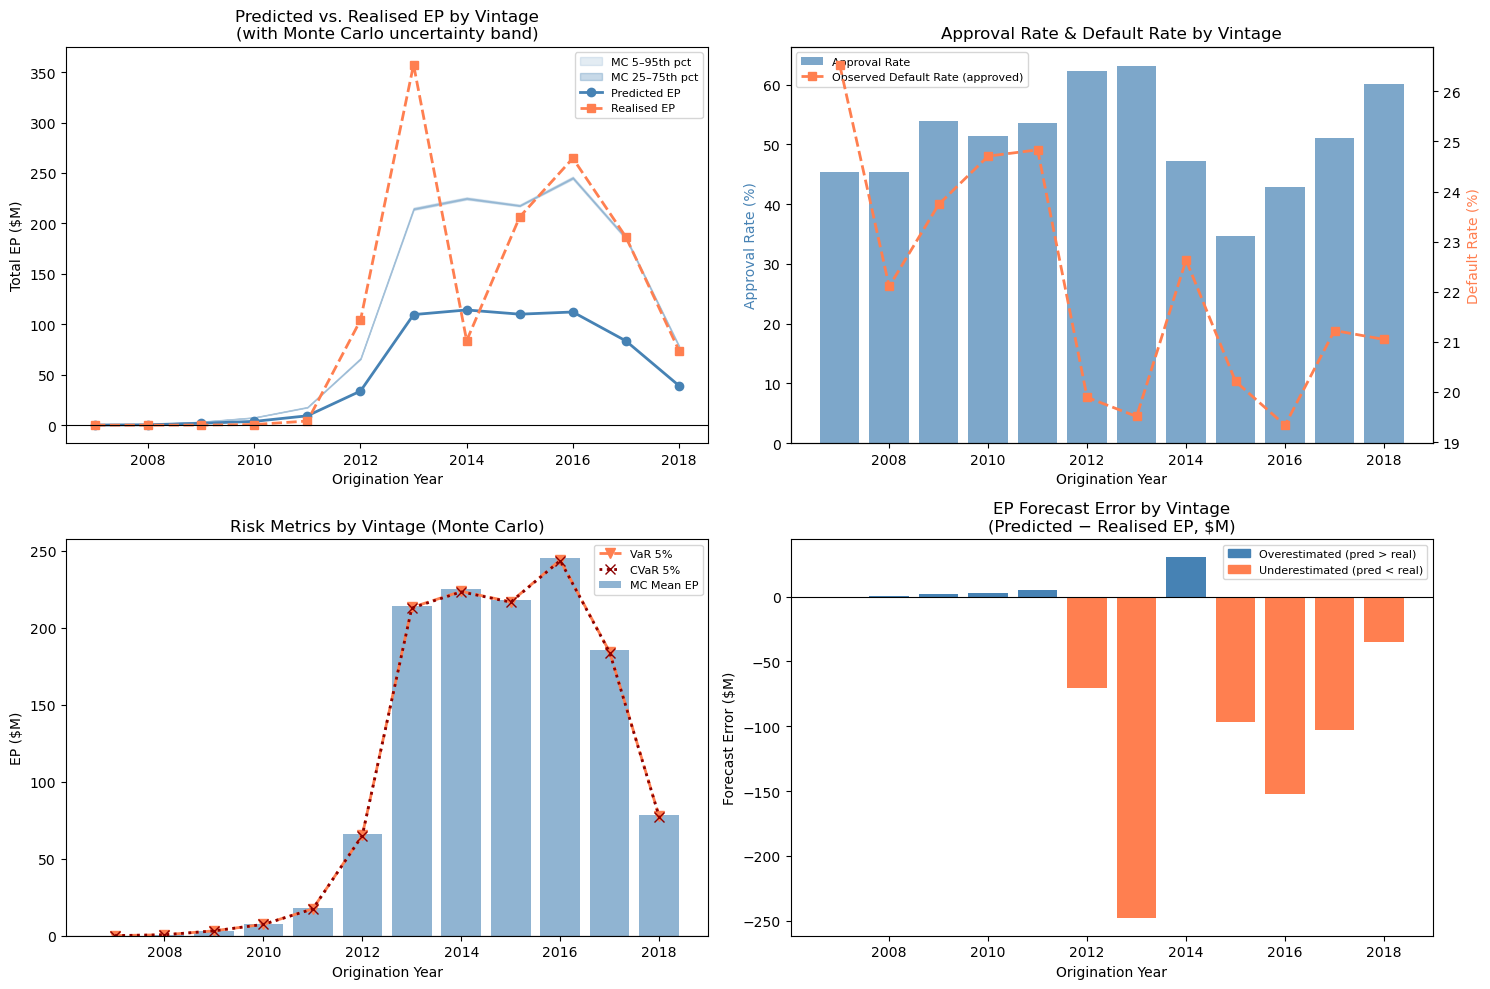

,year,n_approved,approval_rate,obs_default_rate,pred_ep_total,real_ep_total,mc_ep_mean,mc_var_5pct,mc_cvar_5pct,mc_pct_positive
0,2007,114,0.4500,0.2700,"47,730.7200","-75,565.8000","92,382.8600","78,769.1500","74,086.9700",1.0000
1,2008,708,0.4500,0.2200,"313,080.0000","-114,849.8100","642,505.3500","603,469.7300","596,336.0300",1.0000
2,2009,2545,0.5400,0.2400,"1,805,239.4800","-14,570.6300","3,266,859.6200","3,165,684.4500","3,137,491.7500",1.0000
3,2010,5928,0.5100,0.2500,"3,676,099.1700","564,895.4300","7,548,321.1000","7,381,761.7700","7,343,990.5200",1.0000
4,2011,11652,0.5400,0.2500,"9,220,464.5100","3,997,562.1100","17,738,363.9800","17,427,717.6300","17,362,438.9800",1.0000
5,2012,33219,0.6200,0.2000,"33,742,746.7200","104,034,965.7200","65,905,445.0700","65,202,714.2300","65,043,307.1400",1.0000
6,2013,85156,0.6300,0.2000,"109,569,431.3800","357,317,323.9300","214,379,712.3000","213,140,838.6300","212,717,997.8400",1.0000
7,2014,105394,0.4700,0.2300,"114,159,521.4600","83,722,075.0500","224,775,305.8200","223,568,682.2200","223,258,368.6900",1.0000
8,2015,130170,0.3500,0.2000,"109,979,215.8500","206,448,460.2000","217,708,432.7100","216,793,676.0600","216,553,926.9700",1.0000
9,2016,125768,0.4300,0.1900,"112,142,906.5300","264,560,028.7900","245,151,005.4600","243,857,700.0600","243,539,110.2700",1.0000


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

years = bt['year']

# Predicted vs Realised EP with MC band
ax = axes[0, 0]
ax.fill_between(years, bt['mc_ep_p05']/1e6, bt['mc_ep_p95']/1e6,
                alpha=0.15, color='steelblue', label='MC 5–95th pct')
ax.fill_between(years, bt['mc_ep_p25']/1e6, bt['mc_ep_p75']/1e6,
                alpha=0.30, color='steelblue', label='MC 25–75th pct')
ax.plot(years, bt['pred_ep_total']/1e6, 'o-', color='steelblue',
        linewidth=2, label='Predicted EP')
ax.plot(years, bt['real_ep_total']/1e6, 's--', color='coral',
        linewidth=2, label='Realised EP')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Predicted vs. Realised EP by Vintage\n(with Monte Carlo uncertainty band)')
ax.set_xlabel('Origination Year')
ax.set_ylabel('Total EP ($M)')
ax.legend(fontsize=8)

# Approval rate and observed default rate
ax2 = axes[0, 1]
ax2.bar(years, bt['approval_rate'] * 100, color='steelblue', alpha=0.7, label='Approval Rate')
ax2_r = ax2.twinx()
ax2_r.plot(years, bt['obs_default_rate'] * 100, 's--', color='coral',
           linewidth=2, label='Observed Default Rate (approved)')
ax2.set_title('Approval Rate & Default Rate by Vintage')
ax2.set_xlabel('Origination Year')
ax2.set_ylabel('Approval Rate (%)', color='steelblue')
ax2_r.set_ylabel('Default Rate (%)', color='coral')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

# VaR and CVaR by vintage
ax3 = axes[1, 0]
ax3.bar(years, bt['mc_ep_mean']/1e6, color='steelblue', alpha=0.6, label='MC Mean EP')
ax3.plot(years, bt['mc_var_5pct']/1e6, 'v--', color='coral',
         linewidth=2, markersize=7, label='VaR 5%')
ax3.plot(years, bt['mc_cvar_5pct']/1e6, 'x:', color='darkred',
         linewidth=2, markersize=7, label='CVaR 5%')
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_title('Risk Metrics by Vintage (Monte Carlo)')
ax3.set_xlabel('Origination Year')
ax3.set_ylabel('EP ($M)')
ax3.legend(fontsize=8)

# Forecast error (predicted - realised)
bt['forecast_error'] = bt['pred_ep_total'] - bt['real_ep_total']
colors = ['steelblue' if e >= 0 else 'coral' for e in bt['forecast_error']]
ax4 = axes[1, 1]
ax4.bar(years, bt['forecast_error']/1e6, color=colors)
ax4.axhline(0, color='black', linewidth=0.8)
ax4.set_title('EP Forecast Error by Vintage\n(Predicted − Realised EP, $M)')
ax4.set_xlabel('Origination Year')
ax4.set_ylabel('Forecast Error ($M)')
blue_patch = mpatches.Patch(color='steelblue', label='Overestimated (pred > real)')
red_patch  = mpatches.Patch(color='coral',     label='Underestimated (pred < real)')
ax4.legend(handles=[blue_patch, red_patch], fontsize=8)

plt.tight_layout()
plt.show()

display(bt[[
    'year', 'n_approved', 'approval_rate', 'obs_default_rate',
    'pred_ep_total', 'real_ep_total', 'mc_ep_mean',
    'mc_var_5pct', 'mc_cvar_5pct', 'mc_pct_positive'
]].round(2))

## **Aggregate Portfolio Risk Metrics**

Pooling across all vintages gives the aggregate portfolio-level distribution of outcomes.

In [15]:
# Run Monte Carlo on the full approved portfolio (all years combined)
full_approved = df[approval_model.approve(
    df['pd_score'].values, df['lgd_hat'].values, df['ead_hat'].values,
    df['funded_amnt'].values, df['int_rate'].values, df['term'].values
) == 1].copy()

print(f'Full approved book: {len(full_approved):,} loans')
print('Running 1,000 Monte Carlo trials on full portfolio...')

mc_full = monte_carlo_ep(
    full_approved, HURDLE,
    SIGMA_PD, SIGMA_LGD, SIGMA_EAD,
    n_trials=1000, rng=RNG
)

print(f"\nPortfolio EP Distribution (1,000 trials):")
print(f"  Mean EP         : ${mc_full['total_ep_mean']/1e6:>8.1f}M")
print(f"  Std dev         : ${mc_full['total_ep_std']/1e6:>8.1f}M")
print(f"  5th pct (VaR)   : ${mc_full['var_ep_5pct']/1e6:>8.1f}M")
print(f"  CVaR (5%)       : ${mc_full['cvar_ep_5pct']/1e6:>8.1f}M")
print(f"  95th pct        : ${mc_full['total_ep_p95']/1e6:>8.1f}M")
print(f"  % trials with positive EP: {mc_full['pct_positive_ep']:.1%}")

Full approved book: 620,933 loans
Running 1,000 Monte Carlo trials on full portfolio...

Portfolio EP Distribution (1,000 trials):
  Mean EP         : $  1260.9M
  Std dev         : $     1.7M
  5th pct (VaR)   : $  1258.1M
  CVaR (5%)       : $  1257.4M
  95th pct        : $  1263.8M
  % trials with positive EP: 100.0%


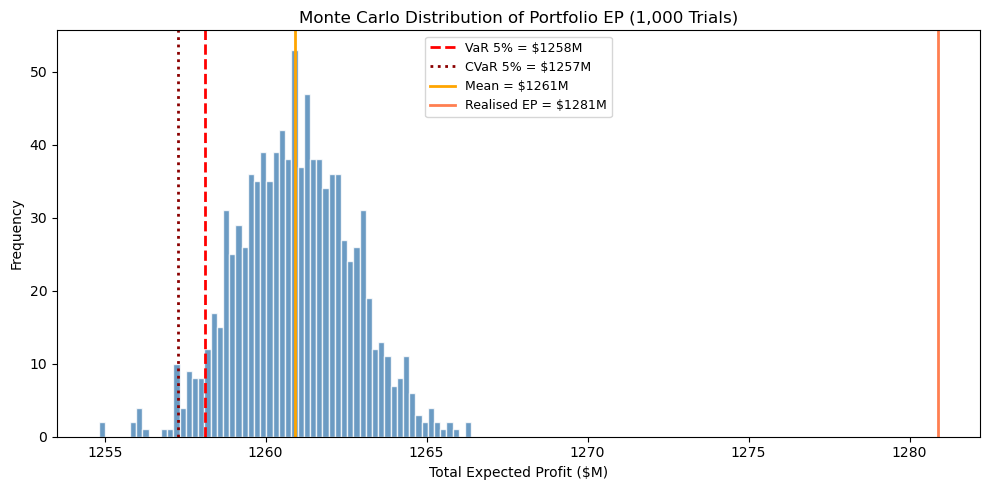

In [16]:
# Re-run to capture full trial array for histogram
# (monte_carlo_ep only returns summary stats; we need the raw array here)
n_trials = 1000
trial_ep = np.zeros(n_trials)

pd_base   = full_approved['pd_score'].values
lgd_base  = full_approved['lgd_hat'].values
ead_r_base= full_approved['ead_ratio_hat'].values
funded    = full_approved['funded_amnt'].values
rate      = full_approved['int_rate'].values

for i in range(n_trials):
    pd_t    = np.clip(pd_base   + RNG.normal(0, SIGMA_PD,  len(full_approved)), 0, 1)
    lgd_t   = np.clip(lgd_base  + RNG.normal(0, SIGMA_LGD, len(full_approved)), 0, 1)
    ead_r_t = np.clip(ead_r_base + RNG.normal(0, SIGMA_EAD, len(full_approved)), 0, 1)
    ead_t   = ead_r_t * funded
    income  = (rate / 100) * funded * (full_approved['term'].values / 12)
    ep_t    = (1 - pd_t) * income - pd_t * lgd_t * ead_t
    ep_r_t  = ep_t / (funded + 1e-9)
    mask    = ep_r_t > HURDLE
    trial_ep[i] = ep_t[mask].sum() if mask.sum() > 0 else 0

var_5   = np.percentile(trial_ep, 5)
cvar_5  = trial_ep[trial_ep <= var_5].mean()
real_ep_full = full_approved['ep_realised'].sum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(trial_ep / 1e6, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(var_5 / 1e6,   color='red',    linestyle='--', linewidth=2, label=f'VaR 5% = ${var_5/1e6:.0f}M')
ax.axvline(cvar_5 / 1e6,  color='darkred',linestyle=':',  linewidth=2, label=f'CVaR 5% = ${cvar_5/1e6:.0f}M')
ax.axvline(trial_ep.mean()/1e6, color='orange', linestyle='-', linewidth=2,
           label=f'Mean = ${trial_ep.mean()/1e6:.0f}M')
ax.axvline(real_ep_full/1e6, color='coral', linestyle='-', linewidth=2,
           label=f'Realised EP = ${real_ep_full/1e6:.0f}M')
ax.set_title('Monte Carlo Distribution of Portfolio EP (1,000 Trials)')
ax.set_xlabel('Total Expected Profit ($M)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## **Hurdle Rate Calibration via Backtest**

The approval model was calibrated on predicted EP. Here we ask: which hurdle rate would have maximised **realised** EP in the backtest — i.e. using actual default outcomes rather than model predictions?

If the realised-optimal hurdle rate differs from the predicted-optimal one, it tells us something about systematic model bias. A hurdle calibrated on realised outcomes is more conservative and accounts for the fact that models tend to be optimistic.

Predicted-optimal hurdle : 0.000  (0.00%)
Realised-optimal hurdle  : 0.000  (0.00%)


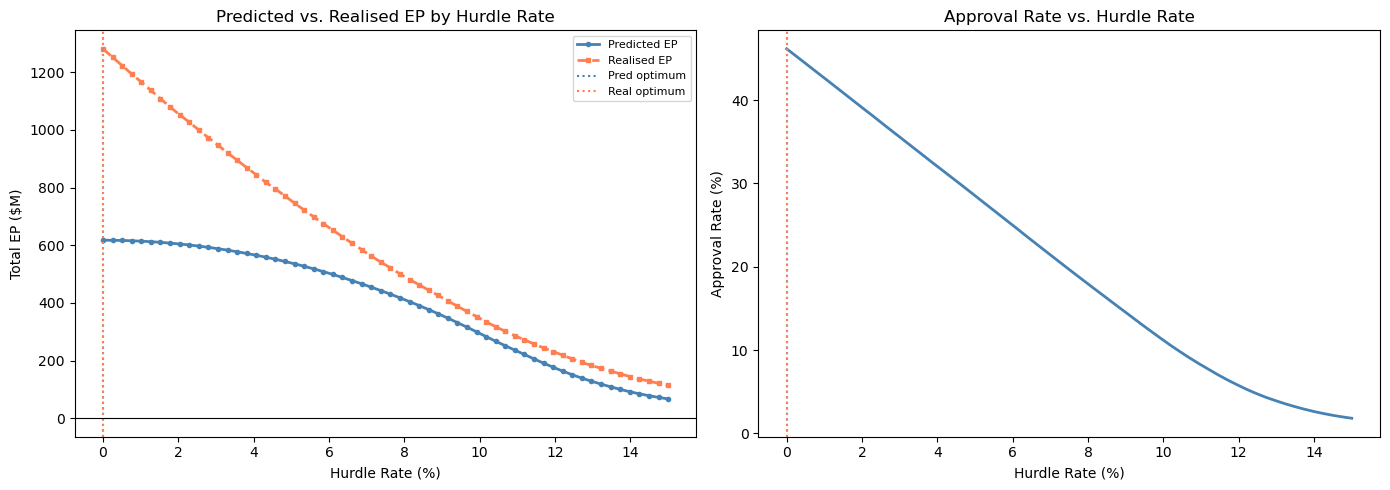

In [17]:
hurdle_grid = np.linspace(0.0, 0.15, 60)
hurdle_results = []

for h in hurdle_grid:
    app = df[df['ep_ratio'] > h]
    if len(app) == 0:
        break
    hurdle_results.append({
        'hurdle':              h,
        'approval_rate':       len(app) / len(df),
        'total_pred_ep':       app['ep'].sum(),
        'total_real_ep':       app['ep_realised'].sum(),
        'mean_pred_ep_ratio':  app['ep_ratio'].mean(),
        'mean_real_ep_ratio':  app['ep_realised_ratio'].mean(),
        'obs_default_rate':    app['is_default_actual'].mean(),
    })

hcal = pd.DataFrame(hurdle_results)

best_pred_idx = hcal['total_pred_ep'].idxmax()
best_real_idx = hcal['total_real_ep'].idxmax()

print(f'Predicted-optimal hurdle : {hcal.loc[best_pred_idx, "hurdle"]:.3f}  '
      f'({hcal.loc[best_pred_idx, "hurdle"]:.2%})')
print(f'Realised-optimal hurdle  : {hcal.loc[best_real_idx, "hurdle"]:.3f}  '
      f'({hcal.loc[best_real_idx, "hurdle"]:.2%})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hcal['hurdle'] * 100, hcal['total_pred_ep'] / 1e6,
             'o-', color='steelblue', linewidth=2, label='Predicted EP', markersize=3)
axes[0].plot(hcal['hurdle'] * 100, hcal['total_real_ep'] / 1e6,
             's--', color='coral', linewidth=2, label='Realised EP', markersize=3)
axes[0].axvline(hcal.loc[best_pred_idx, 'hurdle'] * 100,
                color='steelblue', linestyle=':', linewidth=1.5, label='Pred optimum')
axes[0].axvline(hcal.loc[best_real_idx, 'hurdle'] * 100,
                color='coral', linestyle=':', linewidth=1.5, label='Real optimum')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Predicted vs. Realised EP by Hurdle Rate')
axes[0].set_xlabel('Hurdle Rate (%)')
axes[0].set_ylabel('Total EP ($M)')
axes[0].legend(fontsize=8)

axes[1].plot(hcal['hurdle'] * 100, hcal['approval_rate'] * 100,
             color='steelblue', linewidth=2)
axes[1].axvline(hcal.loc[best_pred_idx, 'hurdle'] * 100,
                color='steelblue', linestyle=':', linewidth=1.5)
axes[1].axvline(hcal.loc[best_real_idx, 'hurdle'] * 100,
                color='coral', linestyle=':', linewidth=1.5)
axes[1].set_title('Approval Rate vs. Hurdle Rate')
axes[1].set_xlabel('Hurdle Rate (%)')
axes[1].set_ylabel('Approval Rate (%)')

plt.tight_layout()
plt.show()

## **Stress Test — Macro Shock Scenarios**

Monte Carlo with increased noise approximates uncertainty but not systematic shocks. A stress test applies a **directional** shock: PDs rise across the board, simulating a credit cycle downturn. I test three shock levels on the full approved book and look at the distribution of EP outcomes under each scenario.

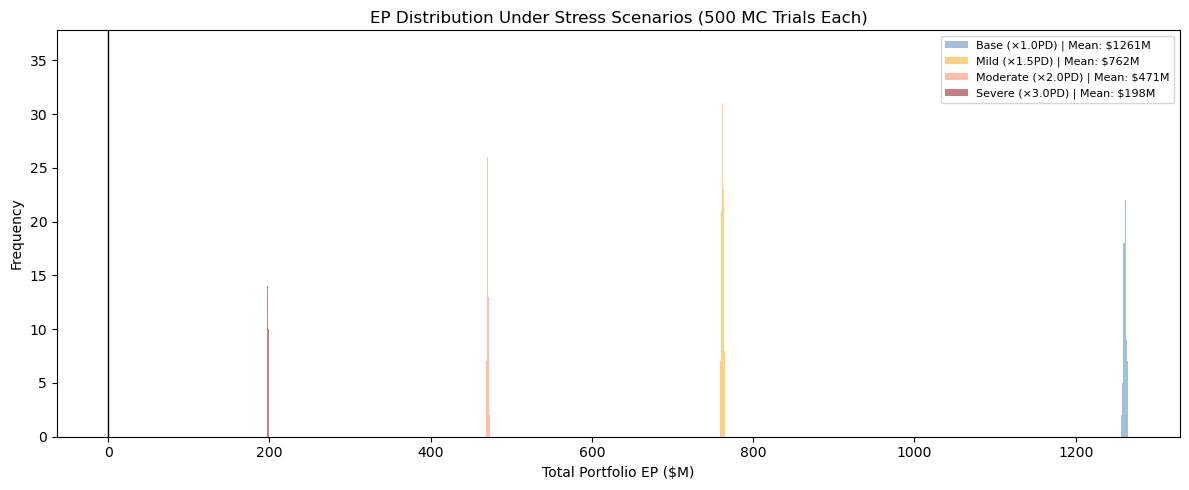

,Scenario,PD Multiplier,Mean EP ($M),VaR 5% ($M),CVaR 5% ($M),% Positive EP
0,Base,1.0000,"1,260.8300","1,257.8600","1,257.0800",100.0000
1,Mild,1.5000,762.1700,760.0300,759.4900,100.0000
2,Moderate,2.0000,470.7800,469.2400,468.9600,100.0000
3,Severe,3.0000,198.2900,197.4800,197.3100,100.0000


In [18]:
stress_scenarios = {
    'Base':     {'pd_mult': 1.0, 'color': 'steelblue'},
    'Mild':     {'pd_mult': 1.5, 'color': 'orange'},
    'Moderate': {'pd_mult': 2.0, 'color': 'coral'},
    'Severe':   {'pd_mult': 3.0, 'color': 'darkred'},
}

N_STRESS = 500
fig, ax = plt.subplots(figsize=(12, 5))

stress_summary = []

for scenario, cfg in stress_scenarios.items():
    mult   = cfg['pd_mult']
    color  = cfg['color']

    s_ep = np.zeros(N_STRESS)
    for i in range(N_STRESS):
        pd_t    = np.clip((pd_base * mult) + RNG.normal(0, SIGMA_PD,  len(full_approved)), 0, 1)
        lgd_t   = np.clip(lgd_base  + RNG.normal(0, SIGMA_LGD, len(full_approved)), 0, 1)
        ead_r_t = np.clip(ead_r_base + RNG.normal(0, SIGMA_EAD, len(full_approved)), 0, 1)
        ead_t   = ead_r_t * funded
        income  = (rate / 100) * funded * (full_approved['term'].values / 12)
        ep_t    = (1 - pd_t) * income - pd_t * lgd_t * ead_t
        ep_r_t  = ep_t / (funded + 1e-9)
        mask    = ep_r_t > HURDLE
        s_ep[i] = ep_t[mask].sum() if mask.sum() > 0 else 0

    ax.hist(s_ep / 1e6, bins=50, alpha=0.5, color=color,
            label=f"{scenario} (×{mult:.1f}PD) | Mean: ${s_ep.mean()/1e6:.0f}M")

    stress_summary.append({
        'Scenario':       scenario,
        'PD Multiplier':  mult,
        'Mean EP ($M)':   s_ep.mean() / 1e6,
        'VaR 5% ($M)':    np.percentile(s_ep, 5) / 1e6,
        'CVaR 5% ($M)':   s_ep[s_ep <= np.percentile(s_ep, 5)].mean() / 1e6,
        '% Positive EP':  (s_ep > 0).mean() * 100,
    })

ax.axvline(0, color='black', linewidth=1)
ax.set_title('EP Distribution Under Stress Scenarios (500 MC Trials Each)')
ax.set_xlabel('Total Portfolio EP ($M)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

display(pd.DataFrame(stress_summary).round(2))

## **Export**

In [19]:
bt.to_csv('backtest_results.csv', index=False)
hcal.to_csv('hurdle_calibration.csv', index=False)
print('Exported: backtest_results.csv')
print('Exported: hurdle_calibration.csv')

# If the realised-optimal hurdle differs meaningfully from the current one,
# update the approval model with the recalibrated rate
HURDLE_RECALIBRATED = hcal.loc[best_real_idx, 'hurdle']
if abs(HURDLE_RECALIBRATED - HURDLE) > 0.005:
    approval_model_recal = type(approval_model)(hurdle_rate=HURDLE_RECALIBRATED)
    joblib.dump(approval_model_recal, 'approval_model_recalibrated.pkl')
    print(f'\nRecalibrated model exported: approval_model_recalibrated.pkl')
    print(f'  Original hurdle : {HURDLE:.4f} ({HURDLE:.2%})')
    print(f'  Recalibrated    : {HURDLE_RECALIBRATED:.4f} ({HURDLE_RECALIBRATED:.2%})')
else:
    print(f'\nHurdle rates are close (diff < 0.5pp) — no recalibration needed.')

Exported: backtest_results.csv
Exported: hurdle_calibration.csv

Hurdle rates are close (diff < 0.5pp) — no recalibration needed.
